In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the CSV files into Pandas DataFrames
baseline_file_path = '240730_Baseline.csv'  # Replace with your file path
resall_file_path = '240730_RESALL_MERGED.csv'  # Replace with your file path

df_baseline = pd.read_csv(baseline_file_path, delimiter=';', quotechar='"')
df_resall = pd.read_csv(resall_file_path, delimiter=';', quotechar='"')

# Assuming 'strategy_param' and other necessary columns exist in these files
# Convert the strategy_param column to numeric, filling NaN values with 0
df_baseline['strategy_param'] = pd.to_numeric(df_baseline['strategy_param'], errors='coerce').fillna(0).astype(int)
df_resall['strategy_param'] = pd.to_numeric(df_resall['strategy_param'], errors='coerce').fillna(0).astype(int)


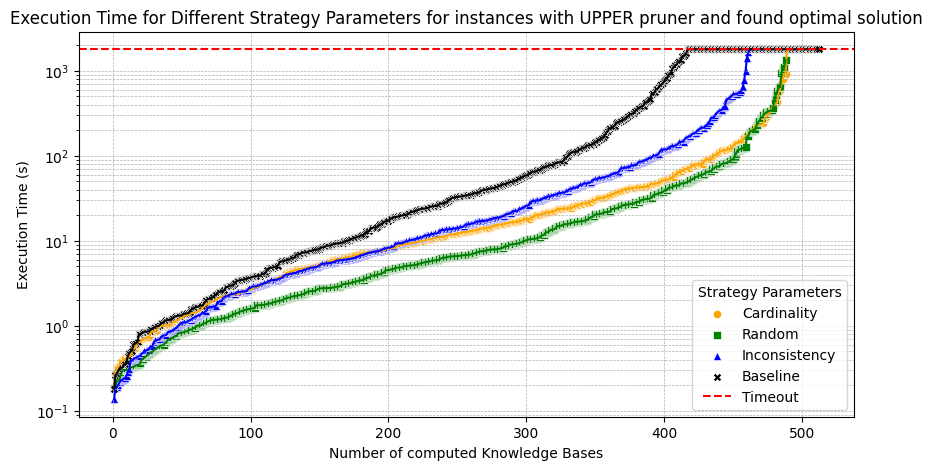

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the CSV files into Pandas DataFrames
baseline_file_path = '240730_Baseline.csv'  # Replace with your file path
resall_file_path = '240730_RESALL_MERGED.csv'  # Replace with your file path

df_baseline = pd.read_csv(baseline_file_path, delimiter=';', quotechar='"')
df_resall = pd.read_csv(resall_file_path, delimiter=';', quotechar='"')

# Assuming 'strategy_param' and other necessary columns exist in these files
# Convert the strategy_param column to numeric, filling NaN values with 0
df_baseline['strategy_param'] = pd.to_numeric(df_baseline['strategy_param'], errors='coerce').fillna(0).astype(int)
df_resall['strategy_param'] = pd.to_numeric(df_resall['strategy_param'], errors='coerce').fillna(0).astype(int)

# Filter the data to include only instances where pruner is 'UPPER', an empty string, or None, shrink_div_conq is 0, and optimal_found is 1
df_filtered_baseline = df_baseline[((df_baseline['pruner'] == 'UPPER') | (df_baseline['pruner'] == 'NONE') | (df_baseline['pruner'].isnull()))]
df_filtered_resall = df_resall[((df_resall['pruner'] == 'UPPER') | (df_resall['pruner'] == 'NONE') | (df_resall['pruner'].isnull()))]

# Get filenames from the filtered df_resall
filenames_resall = df_filtered_resall['filename'].unique()

# Filter df_filtered_baseline to include only filenames that appear in filenames_resall
df_filtered_baseline = df_filtered_baseline[df_filtered_baseline['filename'].isin(filenames_resall)]

# Concatenate the filtered dataframes
df_filtered = pd.concat([df_filtered_baseline, df_filtered_resall])

# Create a mapping for the strategy parameters to different markers and colors
markers = {1: 'o', 2: 's', 3: '^', 0: 'X'}  # Define your strategy parameter markers
palette = {1: 'orange', 2: 'green', 3: 'blue', 0: 'black'}  # Define your strategy parameter colors
labels = {1: 'Cardinality', 2: 'Random', 3: 'Inconsistency', 0: 'Baseline'}  # Custom labels

plt.figure(figsize=(10, 5))

# Plot each strategy parameter separately to apply different markers and colors
for strategy_param, marker in markers.items():
    subset = df_filtered[df_filtered['strategy_param'] == strategy_param]
    if not subset.empty:
        # Sort the subset by execution_time
        subset = subset.sort_values(by='execution_time')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the scatter points
        sns.scatterplot(
            x='counter', 
            y='execution_time', 
            data=subset,
            marker=marker, 
            color=palette[strategy_param], 
            label=labels[strategy_param]  # Use custom labels
        )
        
        # Plot the lines connecting the points
        plt.plot(
            subset['counter'], 
            subset['execution_time'], 
            linestyle='-', 
            color=palette[strategy_param]
        )

# Add a horizontal line for the timeout threshold (if applicable)
timeout_threshold = 1800  # Adjust this threshold as needed
plt.axhline(y=timeout_threshold, color='red', linestyle='--', label='Timeout')

# Customize the plot
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Execution Time for Different Strategy Parameters for instances with UPPER pruner and found optimal solution')
plt.xlabel('Number of computed Knowledge Bases')
plt.ylabel('Execution Time (s)')
plt.legend(title='Strategy Parameters')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.savefig('EVAL_exe_time_UPPER_ALL.png', dpi=300, bbox_inches='tight')
plt.show()


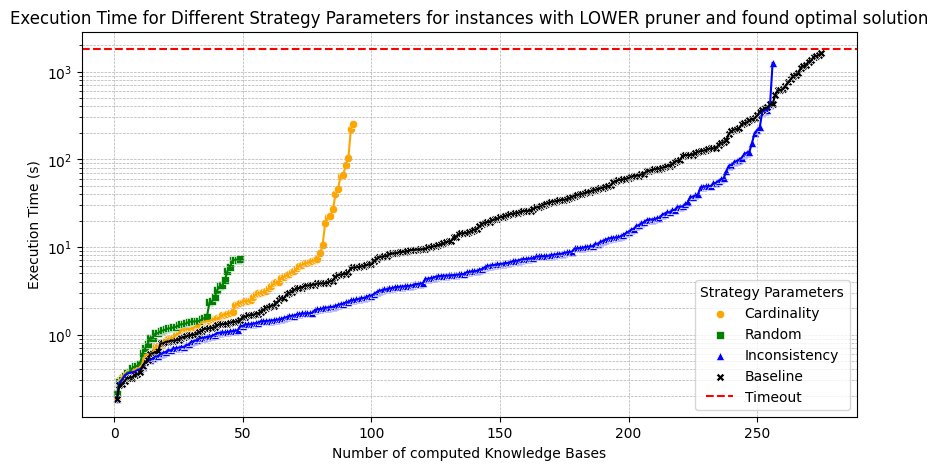

In [51]:
# Filter the data to include only instances where pruner is 'UPPER', an empty string, or None, shrink_div_conq is 0, and optimal_found is 1
df_filtered_baseline = df_baseline[((df_baseline['pruner'] == 'LOWER') | (df_baseline['pruner'] == 'NONE') | (df_baseline['pruner'].isnull()))]
df_filtered_resall = df_resall[((df_resall['pruner'] == 'LOWER') | (df_resall['pruner'] == 'NONE') | (df_resall['pruner'].isnull())) & (df_resall['optimal_found'] == 1)]

# Get filenames from the filtered df_resall
filenames_resall = df_filtered_resall['filename'].unique()

# Filter df_filtered_baseline to include only filenames that appear in filenames_resall
df_filtered_baseline = df_filtered_baseline[df_filtered_baseline['filename'].isin(filenames_resall)]

# Concatenate the filtered dataframes
df_filtered = pd.concat([df_filtered_baseline, df_filtered_resall])

# Create a mapping for the strategy parameters to different markers and colors
markers = {1: 'o', 2: 's', 3: '^', 0: 'X'}  # Define your strategy parameter markers
palette = {1: 'orange', 2: 'green', 3: 'blue', 0: 'black'}  # Define your strategy parameter colors
labels = {1: 'Cardinality', 2: 'Random', 3: 'Inconsistency', 0: 'Baseline'}  # Custom labels

plt.figure(figsize=(10, 5))

# Plot each strategy parameter separately to apply different markers and colors
for strategy_param, marker in markers.items():
    subset = df_filtered[df_filtered['strategy_param'] == strategy_param]
    if not subset.empty:
        # Sort the subset by execution_time
        subset = subset.sort_values(by='execution_time')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the scatter points
        sns.scatterplot(
            x='counter', 
            y='execution_time', 
            data=subset,
            marker=marker, 
            color=palette[strategy_param], 
            label=labels[strategy_param]  # Use custom labels
        )
        
        # Plot the lines connecting the points
        plt.plot(
            subset['counter'], 
            subset['execution_time'], 
            linestyle='-', 
            color=palette[strategy_param]
        )

# Add a horizontal line for the timeout threshold (if applicable)
timeout_threshold = 1800  # Adjust this threshold as needed
plt.axhline(y=timeout_threshold, color='red', linestyle='--', label='Timeout')

# Customize the plot
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Execution Time for Different Strategy Parameters for instances with LOWER pruner and found optimal solution')
plt.xlabel('Number of computed Knowledge Bases')
plt.ylabel('Execution Time (s)')
plt.legend(title='Strategy Parameters')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.savefig('EVAL_exe_time_LOWER_ALL.png', dpi=300, bbox_inches='tight')
plt.show()


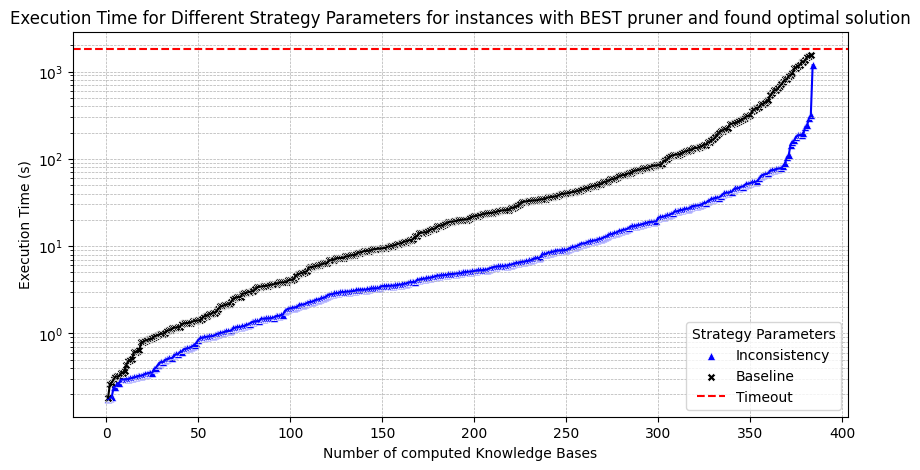

In [53]:
# Filtering data based on the given conditions
df_filtered_baseline = df_baseline[((df_baseline['pruner'] == 'BEST') | (df_baseline['pruner'] == 'NONE') | (df_baseline['pruner'].isnull()))]
df_filtered_resall = df_resall[((df_resall['pruner'] == 'BEST') | (df_resall['pruner'] == 'NONE') | (df_resall['pruner'].isnull())) & (df_resall['strategy_param'] == 3)]

# Get filenames from the filtered df_resall
filenames_resall = df_filtered_resall['filename'].unique()

# Filter df_filtered_baseline to include only filenames that appear in filenames_resall
df_filtered_baseline = df_filtered_baseline[df_filtered_baseline['filename'].isin(filenames_resall)]

# Concatenate the filtered dataframes
df_filtered = pd.concat([df_filtered_baseline, df_filtered_resall])

# Create a mapping for the strategy parameters to different markers and colors
markers = {3: '^', 0: 'X'}  # Define your strategy parameter markers
palette = {3: 'blue', 0: 'black'}  # Define your strategy parameter colors
labels = {3: 'Inconsistency', 0: 'Baseline'}  # Custom labels

plt.figure(figsize=(10, 5))

# Plot each strategy parameter separately to apply different markers and colors
for strategy_param, marker in markers.items():
    subset = df_filtered[df_filtered['strategy_param'] == strategy_param]
    if not subset.empty:
        # Sort the subset by execution_time
        subset = subset.sort_values(by='execution_time')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the scatter points
        sns.scatterplot(
            x='counter', 
            y='execution_time', 
            data=subset,
            marker=marker, 
            color=palette[strategy_param], 
            label=labels[strategy_param]  # Use custom labels
        )
        
        # Plot the lines connecting the points
        plt.plot(
            subset['counter'], 
            subset['execution_time'], 
            linestyle='-', 
            color=palette[strategy_param]
        )

# Add a horizontal line for the timeout threshold (if applicable)
timeout_threshold = 1800  # Adjust this threshold as needed
plt.axhline(y=timeout_threshold, color='red', linestyle='--', label='Timeout')

# Customize the plot
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Execution Time for Different Strategy Parameters for instances with BEST pruner and found optimal solution')
plt.xlabel('Number of computed Knowledge Bases')
plt.ylabel('Execution Time (s)')
plt.legend(title='Strategy Parameters')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.savefig('EVAL_exe_time_BEST_ALL.png', dpi=300, bbox_inches='tight')
plt.show()


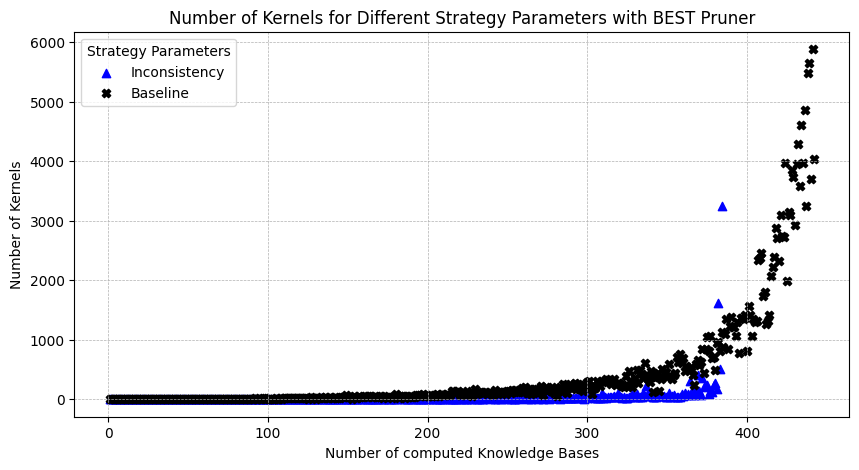

In [35]:

# Filtering data based on the given conditions
df_filtered_baseline = df_baseline[((df_baseline['pruner'] == 'BEST') | (df_baseline['pruner'] == 'NONE') | (df_baseline['pruner'].isnull())) & (df_filtered_baseline['optimal_found'] ==)]
df_filtered_resall = df_resall[((df_resall['pruner'] == 'BEST') | (df_resall['pruner'] == 'NONE') | (df_resall['pruner'].isnull()))]

# Concatenate the filtered dataframes
df_filtered = pd.concat([df_filtered_baseline, df_filtered_resall])

# Create a mapping for the strategy parameters to different markers and colors
markers = {3: '^', 0: 'X'}  # Define your strategy parameter markers
palette = {3: 'blue', 0: 'black'}  # Define your strategy parameter colors
labels = {3: 'Inconsistency', 0: 'Baseline'}  # Custom labels

plt.figure(figsize=(10, 5))

# Plot each strategy parameter separately to apply different markers and colors
for strategy_param, marker in markers.items():
    subset = df_filtered[df_filtered['strategy_param'] == strategy_param]
    if not subset.empty:
        # Sort the subset by execution_time
        subset = subset.sort_values(by='execution_time')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the scatter points
        plt.scatter(
            subset['counter'], 
            subset['num_kernels'], 
            marker=marker, 
            color=palette[strategy_param], 
            label=labels[strategy_param] if strategy_param not in plt.gca().get_legend_handles_labels()[1] else ""
        )

# Customize the plot
plt.title('Number of Kernels for Different Strategy Parameters with BEST Pruner')
plt.xlabel('Number of computed Knowledge Bases')
plt.ylabel('Number of Kernels')
plt.legend(title='Strategy Parameters')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.savefig('EVAL_num_kernels_BEST_ALL.png', dpi=300, bbox_inches='tight')
plt.show()


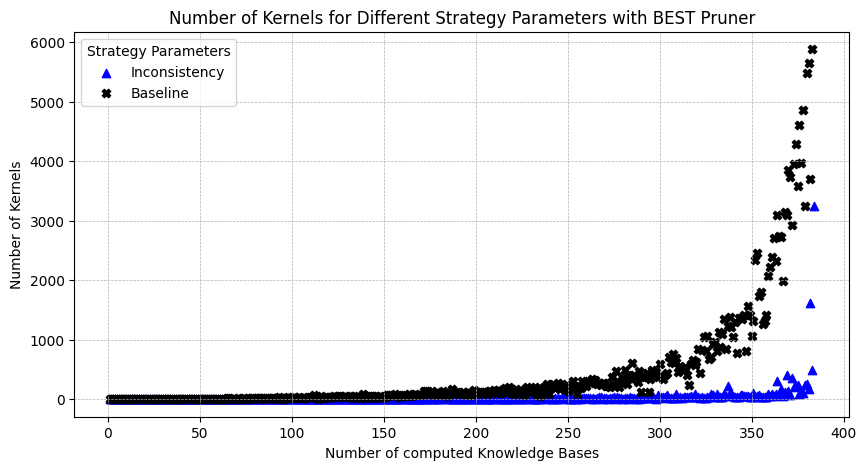

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataframes (assuming they are in CSV files for example)
# df_baseline = pd.read_csv('path_to_baseline.csv')
# df_resall = pd.read_csv('path_to_resall.csv')

# Filtering data based on the given conditions
df_filtered_baseline = df_baseline[((df_baseline['pruner'] == 'BEST') | (df_baseline['pruner'] == 'NONE') | (df_baseline['pruner'].isnull()))]
df_filtered_resall = df_resall[((df_resall['pruner'] == 'BEST') | (df_resall['pruner'] == 'NONE') | (df_resall['pruner'].isnull())) & (df_resall['strategy_param'] == 3)]

# Get filenames from the filtered df_resall
filenames_resall = df_filtered_resall['filename'].unique()

# Filter df_filtered_baseline to include only filenames that appear in filenames_resall
df_filtered_baseline = df_filtered_baseline[df_filtered_baseline['filename'].isin(filenames_resall)]

# Concatenate the filtered dataframes
df_filtered = pd.concat([df_filtered_baseline, df_filtered_resall])

# Create a mapping for the strategy parameters to different markers and colors
markers = {3: '^', 0: 'X'}  # Define your strategy parameter markers
palette = {3: 'blue', 0: 'black'}  # Define your strategy parameter colors
labels = {3: 'Inconsistency', 0: 'Baseline'}  # Custom labels

plt.figure(figsize=(10, 5))

# Plot each strategy parameter separately to apply different markers and colors
for strategy_param, marker in markers.items():
    subset = df_filtered[df_filtered['strategy_param'] == strategy_param]
    if not subset.empty:
        # Sort the subset by execution_time
        subset = subset.sort_values(by='execution_time')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the scatter points
        plt.scatter(
            subset['counter'], 
            subset['num_kernels'], 
            marker=marker, 
            color=palette[strategy_param], 
            label=labels[strategy_param] if strategy_param not in plt.gca().get_legend_handles_labels()[1] else ""
        )

# Customize the plot
plt.title('Number of Kernels for Different Strategy Parameters with BEST Pruner')
plt.xlabel('Number of computed Knowledge Bases')
plt.ylabel('Number of Kernels')
plt.legend(title='Strategy Parameters')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save or display the plot
plt.savefig('EVAL_num_kernels_BEST_ALL_FN.png', dpi=300, bbox_inches='tight')
plt.show()


/var/folders/c8/vvqnn_3x4kjfbl2f05wnkv3c0000gn/T/ipykernel_9189/3940399319.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='relative_time_diff_category', data=df_merged, palette='viridis')


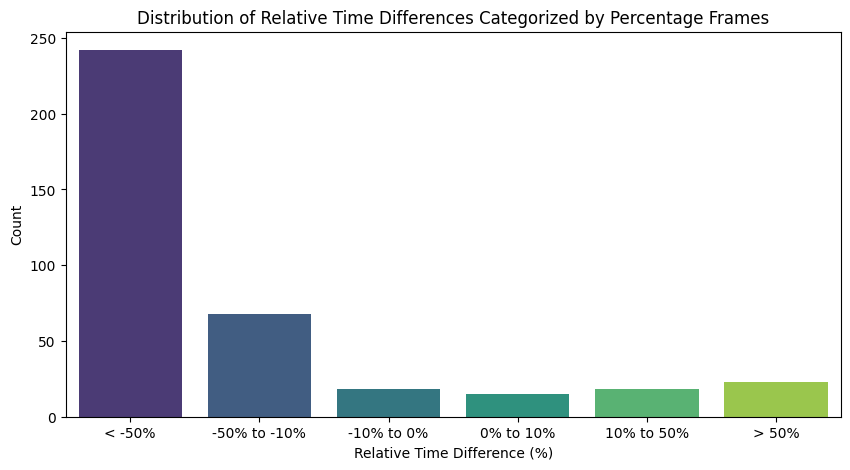

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataframes (assuming they are in CSV files for example)
# df_baseline = pd.read_csv('path_to_baseline.csv')
# df_resall = pd.read_csv('path_to_resall.csv')

# Filtering data based on the given conditions
df_filtered_baseline = df_baseline[((df_baseline['pruner'] == 'BEST') | (df_baseline['pruner'] == 'NONE') | (df_baseline['pruner'].isnull()))]
df_filtered_resall = df_resall[((df_resall['pruner'] == 'BEST') | (df_resall['pruner'] == 'NONE') | (df_resall['pruner'].isnull())) & (df_resall['strategy_param'] == 3)]

# Get filenames from the filtered df_resall
filenames_resall = df_filtered_resall['filename'].unique()

# Filter df_filtered_baseline to include only filenames that appear in filenames_resall
df_filtered_baseline = df_filtered_baseline[df_filtered_baseline['filename'].isin(filenames_resall)]

# Merge the filtered dataframes on filename
df_merged = pd.merge(df_filtered_baseline, df_filtered_resall, on='filename', suffixes=('_baseline', '_resall'))

# Calculate the relative time differences as percentages
df_merged['relative_time_difference'] = ((df_merged['execution_time_resall'] - df_merged['execution_time_baseline']) / df_merged['execution_time_baseline']) * 100

# Categorize the relative time differences into percentage bins
bins = [-float('inf'), -50, -10, 0, 10, 50, float('inf')]
labels = ['< -50%', '-50% to -10%', '-10% to 0%', '0% to 10%', '10% to 50%', '> 50%']
df_merged['relative_time_diff_category'] = pd.cut(df_merged['relative_time_difference'], bins=bins, labels=labels)

# Plot the distribution of relative time differences
plt.figure(figsize=(10, 5))
sns.countplot(x='relative_time_diff_category', data=df_merged, palette='viridis')

# Customize the plot
plt.title('Distribution of Relative Time Differences Categorized by Percentage Frames')
plt.xlabel('Relative Time Difference (%)')
plt.ylabel('Count')

# Save or display the plot
plt.savefig('relative_time_difference_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


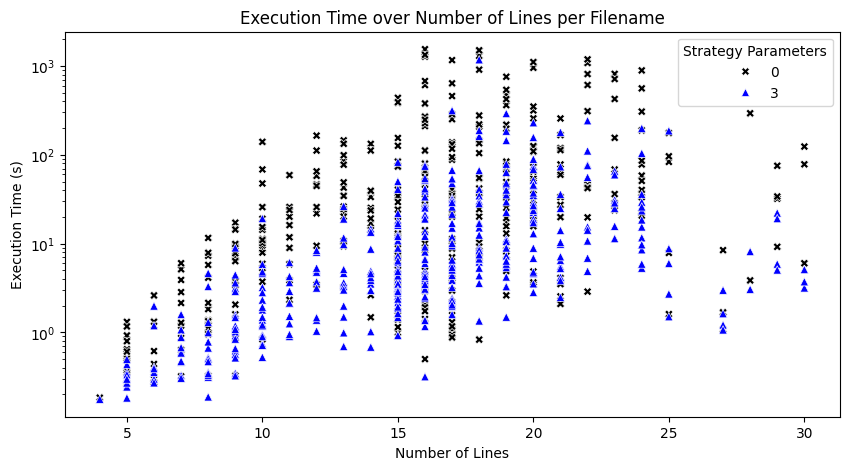

In [65]:

df_data_sets = pd.read_csv('240730_DATA_SETS.csv', delimiter=';')

# Filtering data based on the given conditions
df_filtered_baseline = df_baseline[((df_baseline['pruner'] == 'BEST') | (df_baseline['pruner'] == 'NONE') | (df_baseline['pruner'].isnull()))]
df_filtered_resall = df_resall[((df_resall['pruner'] == 'BEST') | (df_resall['pruner'] == 'NONE') | (df_resall['pruner'].isnull())) & (df_resall['strategy_param'] == 3)]

# Get filenames from the filtered df_resall
filenames_resall = df_filtered_resall['filename'].unique()

# Filter df_filtered_baseline to include only filenames that appear in filenames_resall
df_filtered_baseline = df_filtered_baseline[df_filtered_baseline['filename'].isin(filenames_resall)]

# Concatenate the filtered dataframes
df_filtered = pd.concat([df_filtered_baseline, df_filtered_resall])

# Merge the concatenated dataframe with the data sets dataframe to get the number of lines
df_merged_with_lines = pd.merge(df_filtered, df_data_sets[['filename', 'number_lines']], on='filename')

# Create a scatter plot of execution time over the number of lines per filename
plt.figure(figsize=(10, 5))
sns.scatterplot(x='number_lines', y='execution_time', hue='strategy_param', data=df_merged_with_lines, palette={3: 'blue', 0: 'black'}, style='strategy_param', markers={3: '^', 0: 'X'})

# Customize the plot
plt.title('Execution Time over Number of Lines per Filename')
plt.xlabel('Number of Lines')
plt.ylabel('Execution Time (s)')
plt.legend(title='Strategy Parameters')
plt.yscale('log')

# Save or display the plot
plt.savefig('execution_time_over_number_of_lines.png', dpi=300, bbox_inches='tight')
plt.show()